In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

### Feature Scaling and Feature Selection

Direction
Up      648
Down    602
Name: count, dtype: int64


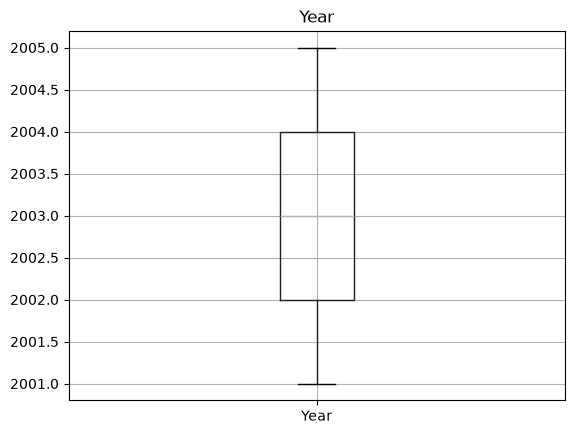

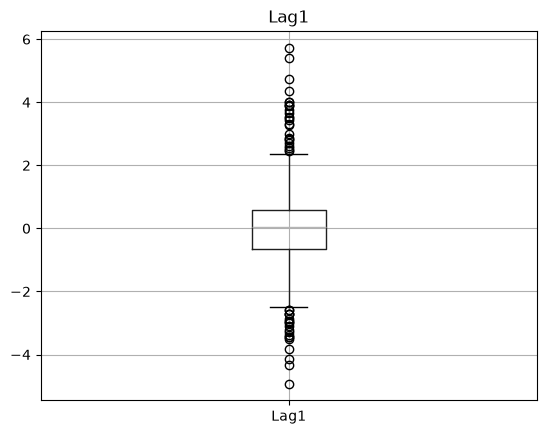

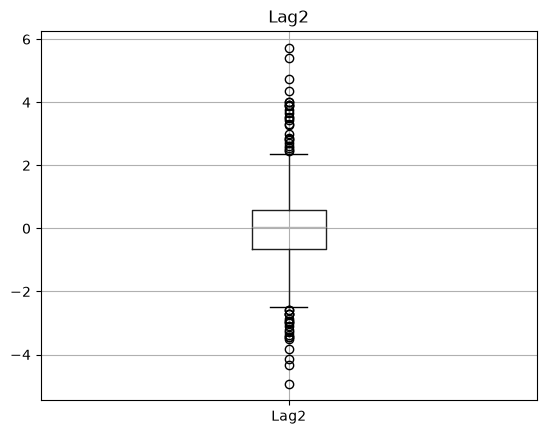

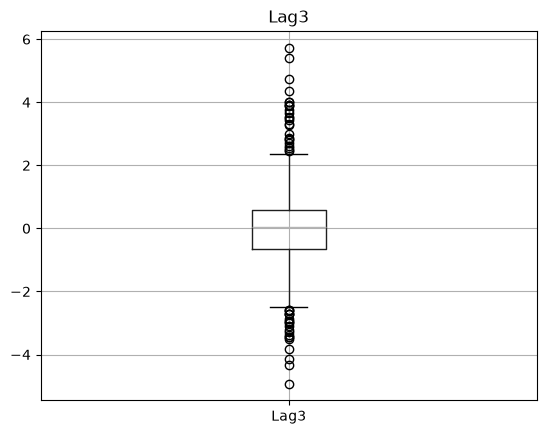

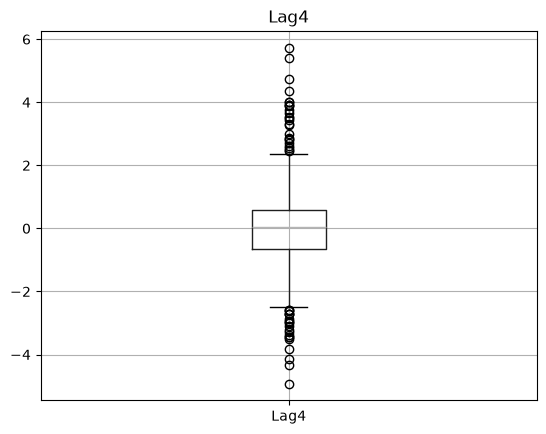

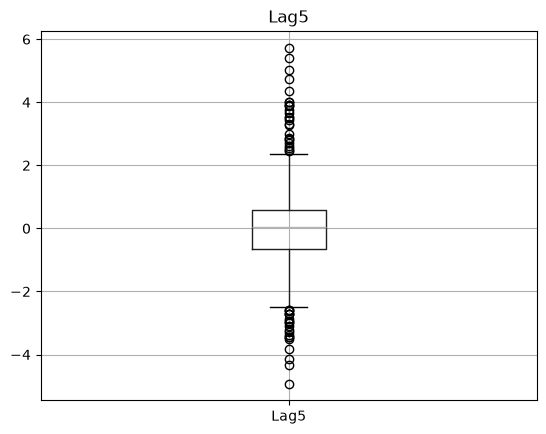

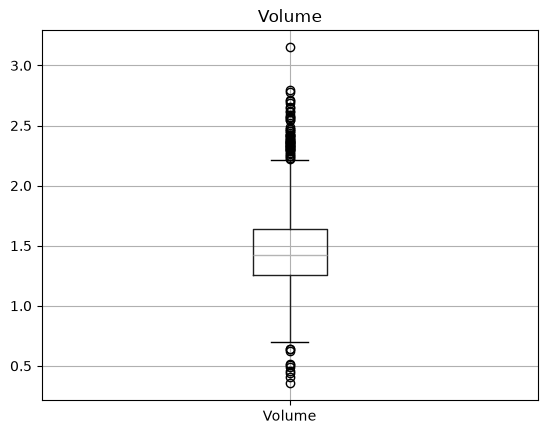

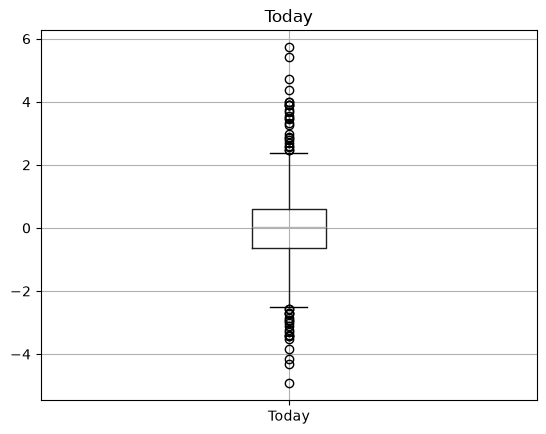

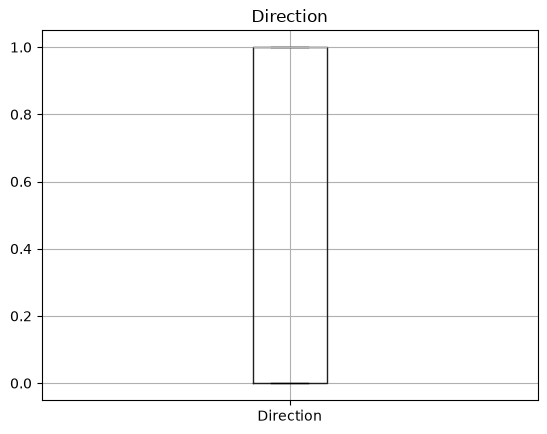

In [2]:
#Understanding the dataset
df=pd.read_csv('./dataset/Smarket.csv')
df.dropna()
df.describe()
print(df["Direction"].value_counts())

#Encoding the target variable 
df["Direction"] = df["Direction"].map({
    "Up":1,
    "Down":0
})
#df.hist(figsize=(15,12))
for col in df.columns:
    df.boxplot(column=col)
    plt.title(col) 
    plt.show()
    

In [3]:
SEED = 445
train_set= df.sample(frac=0.75,random_state=SEED)
test_set=df.drop(train_set.index)

X_train=train_set.drop("Direction",axis=1)
Y_train=train_set["Direction"].copy()

X_test=test_set.drop("Direction",axis=1)
Y_test=test_set["Direction"].copy()

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

#Scaling 
#From the boxplot its clear that the dataset has lot of outliers . So we will use robust scaling to scale the df
median=X_train.median()
q1=X_train.quantile(0.25)
q3=X_train.quantile(0.75)
IQR=q3-q1
X_train_scaled=(X_train-median)/IQR
X_test_scaled=(X_test-median)/IQR

X_train_scaled.boxplot(figsize=(15,12))
X_train_scaled.isnull().sum()

Shape of X_train: (938, 8)
Shape of X_test: (312, 8)


Year      0
Lag1      0
Lag2      0
Lag3      0
Lag4      0
Lag5      0
Volume    0
Today     0
dtype: int64

### Sigmoid and Logistic Loss

In [4]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def logistic_loss(X,y, w,b, lbd):
    m ,n= X.shape
    loss = 0.0
    reg = 0.0
    for i in range(m):
        z = np.dot(X[i],w)+b
        f_wb = sigmoid(z)
        loss += -y[i]*np.log(f_wb) - (1-y[i])*np.log(1-f_wb) 

    for i in range(n):
        reg += w[i]**2

    reg_term = (lbd/(2*m)) * reg

    total_cost = (loss/m) + reg_term
        
    return total_cost


In [5]:
def compute_gradient(X, y, w, b, lbd):
    m, n = X.shape

    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        z = np.dot(X[i], w) + b
        f_wb = sigmoid(z)
        error = f_wb - y[i]

        dj_db += error

        for j in range(n):
            dj_dw[j] += error * X[i, j]

    

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    for j in range(n):
        dj_dw[j] += (lbd / m) * w[j]

    return dj_dw, dj_db

def gradient_descent(X_train, y_train, compute_cost, compute_gradient, l_rate, iter, w_i, b_i, lbd):

    J_hist = []
    param_hist = []
    iteration = []
    b = b_i
    w = w_i


    for i in range(iter):
        dj_dw,dj_db = compute_gradient(X_train,y_train, w, b, lbd)

        w = w - (dj_dw * l_rate)
        b = b - (dj_db * l_rate)

       

        if(i%(math.ceil(iter/10)) == 0):
            iteration.append(i)
            J_hist.append(compute_cost(X_train, y_train, w,b,lbd))
            param_hist.append([w,b])
            print(f"iteration: {i} || Cost: {J_hist[-1]}")

            
    return w,b, J_hist, param_hist, iteration


In [45]:
def viewCost(cost):
    plt.plot(cost, c='r')
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.title("Cost VS Iteration")
    plt.show()


def predict(w,X,b):
    return sigmoid(np.dot(X,w)+b)


iteration: 0 || Cost: 0.6919908857930168
iteration: 100 || Cost: 0.5981585824457176
iteration: 200 || Cost: 0.5349047404588084
iteration: 300 || Cost: 0.4894516986824112
iteration: 400 || Cost: 0.45493992758426943
iteration: 500 || Cost: 0.42761666772145807
iteration: 600 || Cost: 0.4052905064430471
iteration: 700 || Cost: 0.38659773153322746
iteration: 800 || Cost: 0.3706429003544738
iteration: 900 || Cost: 0.35681154476920657
Train Accuracy: 97.12153518123668
Test Accuracy: 97.11538461538461


iteration: 0 || Cost: 0.6919908860395377
iteration: 100 || Cost: 0.5981623741710513
iteration: 200 || Cost: 0.53491661783519
iteration: 300 || Cost: 0.4894735483289201
iteration: 400 || Cost: 0.4549726703376164
iteration: 500 || Cost: 0.4276607786685876
iteration: 600 || Cost: 0.40534622901732736
iteration: 700 || Cost: 0.3866651786069361
iteration: 800 || Cost: 0.37072210708966374
iteration: 900 || Cost: 0.35690249835808135
Train Accuracy: 97.12153518123668
Test Accuracy: 97.11538461538461


i

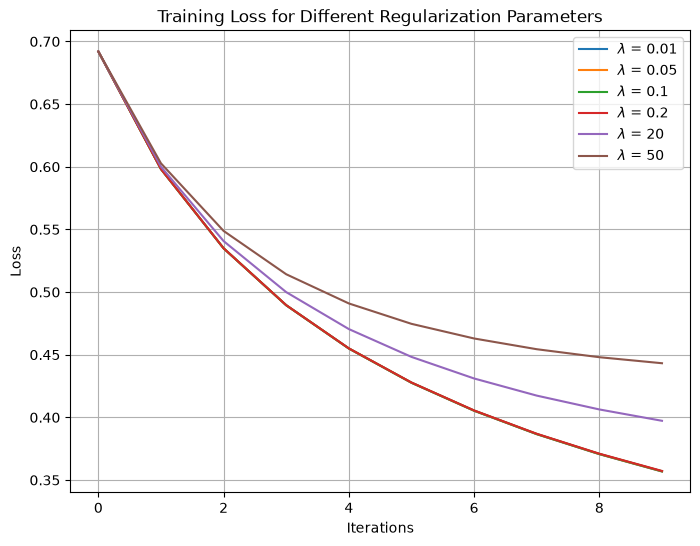

In [50]:
X_np = X_train_scaled.to_numpy()
X_test_np = X_test_scaled.to_numpy()
y_np = Y_train.to_numpy()
Y_test_np = Y_test.to_numpy()
m,n = X_train.shape
w = np.zeros(n)
b = 0.0
regularize = [0.01, 0.05, 0.1, 0.2,20,50]
loss_history = {}

for reg in regularize:
    w = np.zeros(n)
    b = 0.0
    w,b, J_hist, param_hist, iteration = gradient_descent(X_np, y_np,logistic_loss,compute_gradient, 0.01, 1000,w,b, reg)
    # viewCost(J_hist)
    loss_history[reg] = J_hist

    y_train_prob = predict(w, X_train_scaled,b)
    y_train_pred = np.where(y_train_prob>=0.5, 1,0)
    y_train_pred = y_train_pred.flatten()

    y_test_prob = predict(w,X_test_np, b)

    y_test_pred = np.where(y_test_prob>=0.5, 1,0)
    y_test_pred = y_test_pred.flatten()
    is_correct_test = (y_test_pred == Y_test_np)
    is_correct_train = (y_train_pred == Y_train)


    true_count_test = np.count_nonzero(is_correct_test == True)
    true_count_train = np.count_nonzero(is_correct_train == True)
    print(f"Train Accuracy: {(true_count_train/len(is_correct_train))*100}")
    print(f"Test Accuracy: {(true_count_test/len(is_correct_test))*100}")
    print('\n')



plt.figure(figsize=(8,6))

for reg, losses in loss_history.items():
    plt.plot(losses, label=f"$\\lambda$ = {reg}")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss for Different Regularization Parameters")
plt.legend()
plt.grid(True)
plt.show()